In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [18]:
def stat_reader(fname):
    f=open(fname)
    try:
        stat_dict = ast.literal_eval(f.readlines()[-1].strip())
    except Exception as e:
        stat_dict="failed_rank"
    # print(stat_dict)
    return stat_dict


In [95]:
#valid checks -> bramble-4-1, bramble-4-5, bramble-2-5
iters=30
per_bank_stats={}
for repeat in [1,3,4,5]:
    for pdu_tag in ["bramble-4-1", "bramble-4-5", "bramble-2-5"]:
        if pdu_tag not in per_bank_stats:
            per_bank_stats[pdu_tag]={}
        for world in [1,2,3,4,5]:
            if world not in per_bank_stats[pdu_tag]:
                per_bank_stats[pdu_tag][world] = {}
            for con in [1,3,5]:
                if con not in per_bank_stats[pdu_tag][world]:
                    per_bank_stats[pdu_tag][world][con] = {}
                
                for dev in range(1,43):
                    maybe_path = f"/Users/animeshnd/model_splitting/logs/roofline/{pdu_tag}/resnet18_children/{repeat}/con_{con*world}_{con}_{world}/{world}_size/1_1/speed_chronos{pdu_tag}-{dev}.log"
                    if Path.is_file(Path(maybe_path)):
                        stats = stat_reader(maybe_path)
                        if f"{stats}" == "failed_rank":
                            per_bank_stats[pdu_tag][world][con]=0
                            print(maybe_path)
                            break

                        rank=stats["rank"]
                        if rank not in per_bank_stats[pdu_tag][world][con]:
                            per_bank_stats[pdu_tag][world][con][rank]={"comp_times":[i for i in stats["comp_times"]], 
                            "net_times": [i for i in stats["net_times"]], "total_times":[i for i in stats["total_times"]], 
                            "warmup":[i for i in stats["warmup"]]}
                        else:
                            for k in per_bank_stats[pdu_tag][world][con][rank]:
                                per_bank_stats[pdu_tag][world][con][rank][k].extend([i for i in stats[k]])

                        # raise Exception("end it")
# print(per_bank_stats["bramble-2-5"])
print(per_bank_stats["bramble-2-5"][1])
print(per_bank_stats["bramble-2-5"][2])
print(per_bank_stats["bramble-2-5"][3])
            
print()
print(per_bank_stats["bramble-4-5"][1])
# print(per_bank_stats["bramble-4-5"][2])
print(per_bank_stats["bramble-4-5"][3])
# print(per_bank_stats["bramble-4-5"][4])
print()
print(per_bank_stats["bramble-4-1"][1])
print(per_bank_stats["bramble-4-1"][2])

/Users/animeshnd/model_splitting/logs/roofline/bramble-4-5/resnet18_children/1/con_6_3_2/2_size/1_1/speed_chronosbramble-4-5-16.log
/Users/animeshnd/model_splitting/logs/roofline/bramble-4-5/resnet18_children/1/con_12_3_4/4_size/1_1/speed_chronosbramble-4-5-14.log
{1: {0: {'comp_times': [155.70644264796283, 149.6151870249305, 147.5864665149711, 171.10538823902607], 'net_times': [], 'total_times': [155.71538036398124, 149.6394977789605, 147.6139153209515, 171.11767814611085], 'warmup': [10.78730297088623, 0.0, 2.933681075845129e-11, 29.057891845703125]}}, 3: {}, 5: {}}
{1: {1: {'comp_times': [91.6054032020038, 4591.1543774649035, 7478.990430284059, 113.71491989889182], 'net_times': [29.553132664994337, 28.829639723990113, 47.76425993000157, 48.50120509485714], 'total_times': [121.18350388796534, 4620.047436332097, 7526.8223887181375, 162.26300573907793], 'warmup': [4.279801368713379, 6.531737327575684, 6.152318954467773, 0.0]}, 0: {'comp_times': [29.522852158988826, 28.80097727617249, 4

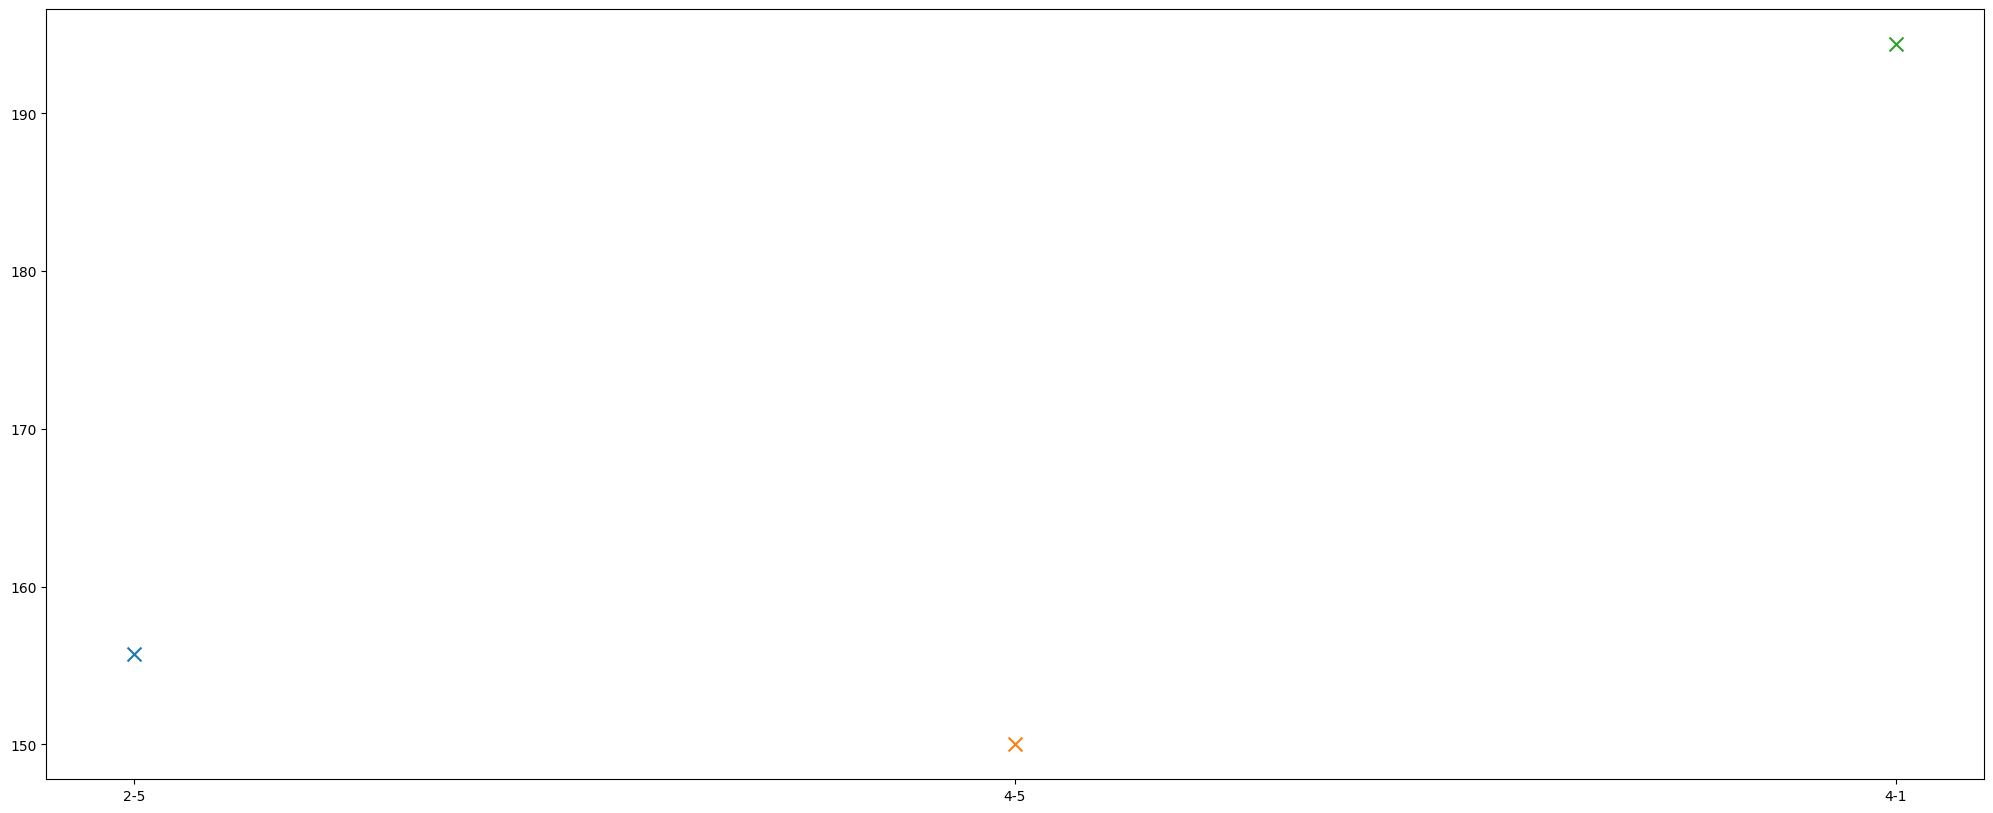

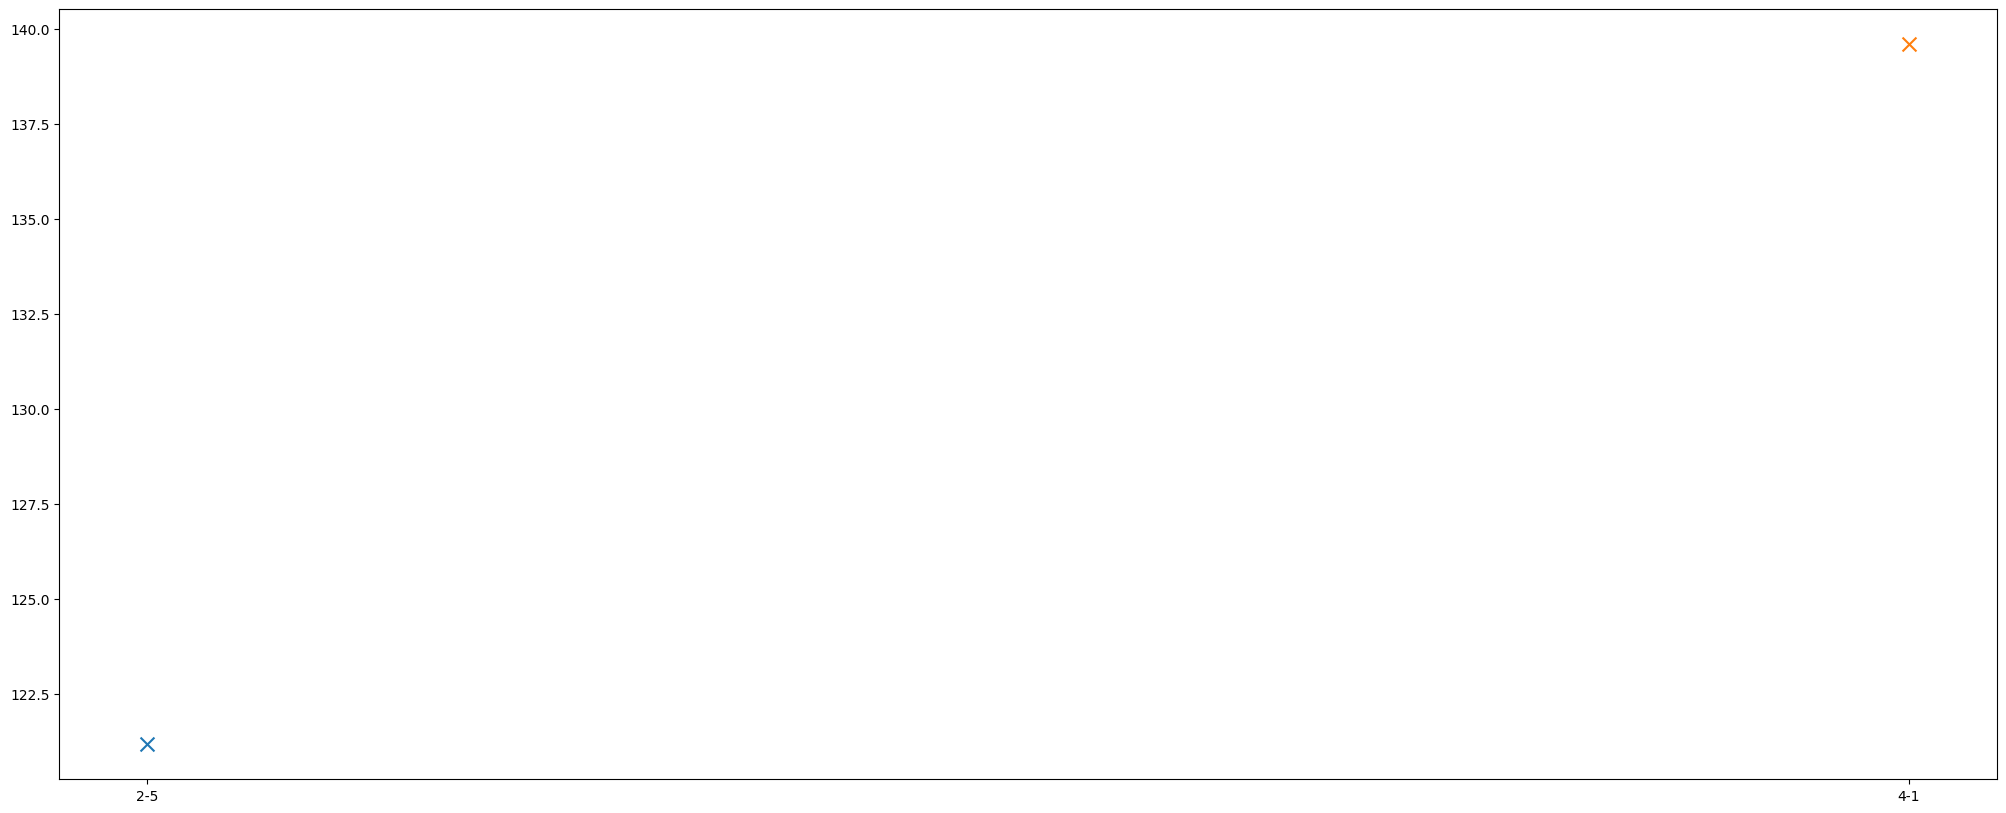

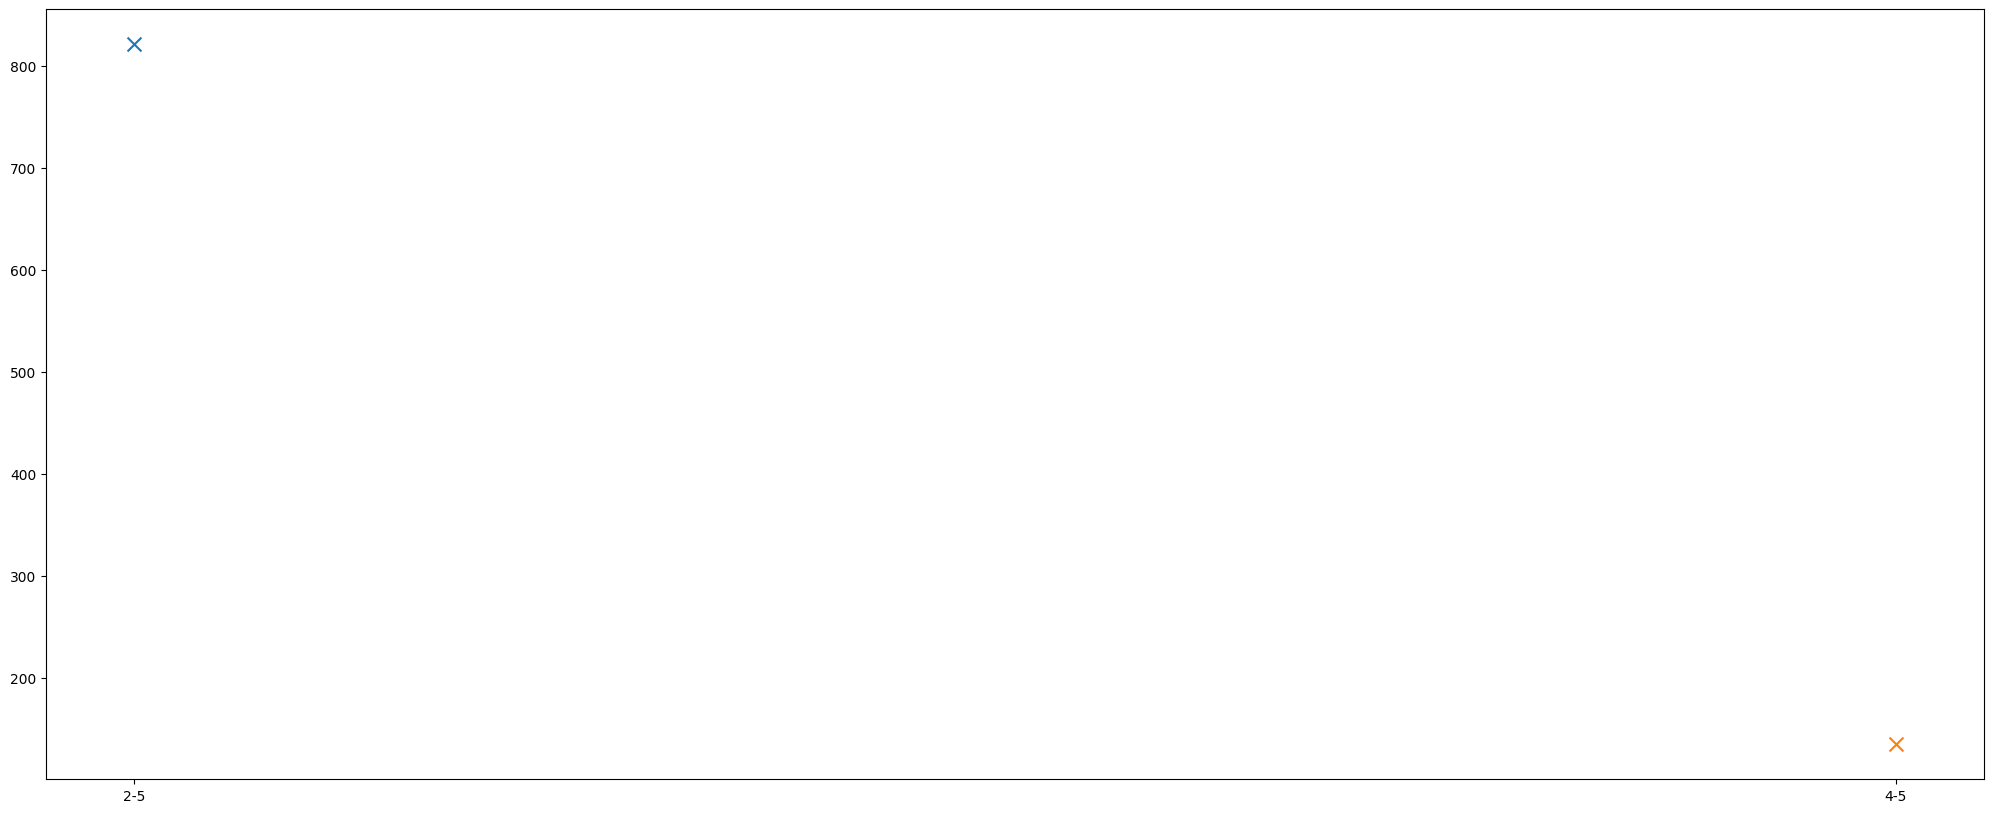

In [87]:
fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
# world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["total_times"][k]/30 -  per_bank_stats["bramble-2-5"][1][1][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
# world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["total_times"][k]/30 -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
# world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["total_times"][k]/30 -  per_bank_stats["bramble-4-1"][1][5][0]["warmup"][k]) for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]
den = 1#(iters+1)

world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["total_times"][k]/den) for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]

world_1_con_1_comp = [i for i in world_1_con_1_comp if i>0]
world_1_con_3_comp = [i for i in world_1_con_3_comp if i>0]
world_1_con_5_comp = [i for i in world_1_con_5_comp if i>0]
# axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)

# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_1_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_1_con_3_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["total_times"][k]/den - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["comp_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]

world_2_con_1_comp = [i for i in world_2_con_1_comp if i >0]
world_2_con_5_comp = [i for i in world_2_con_5_comp if i >0]

# axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)

# axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_2_con_5_comp), marker="x", s=100)


fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]

world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["total_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["comp_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_1_comp = [i for i in world_3_con_1_comp if i > 0]
world_3_con_3_comp = [i for i in world_3_con_3_comp if i > 0]

# axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


# axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)

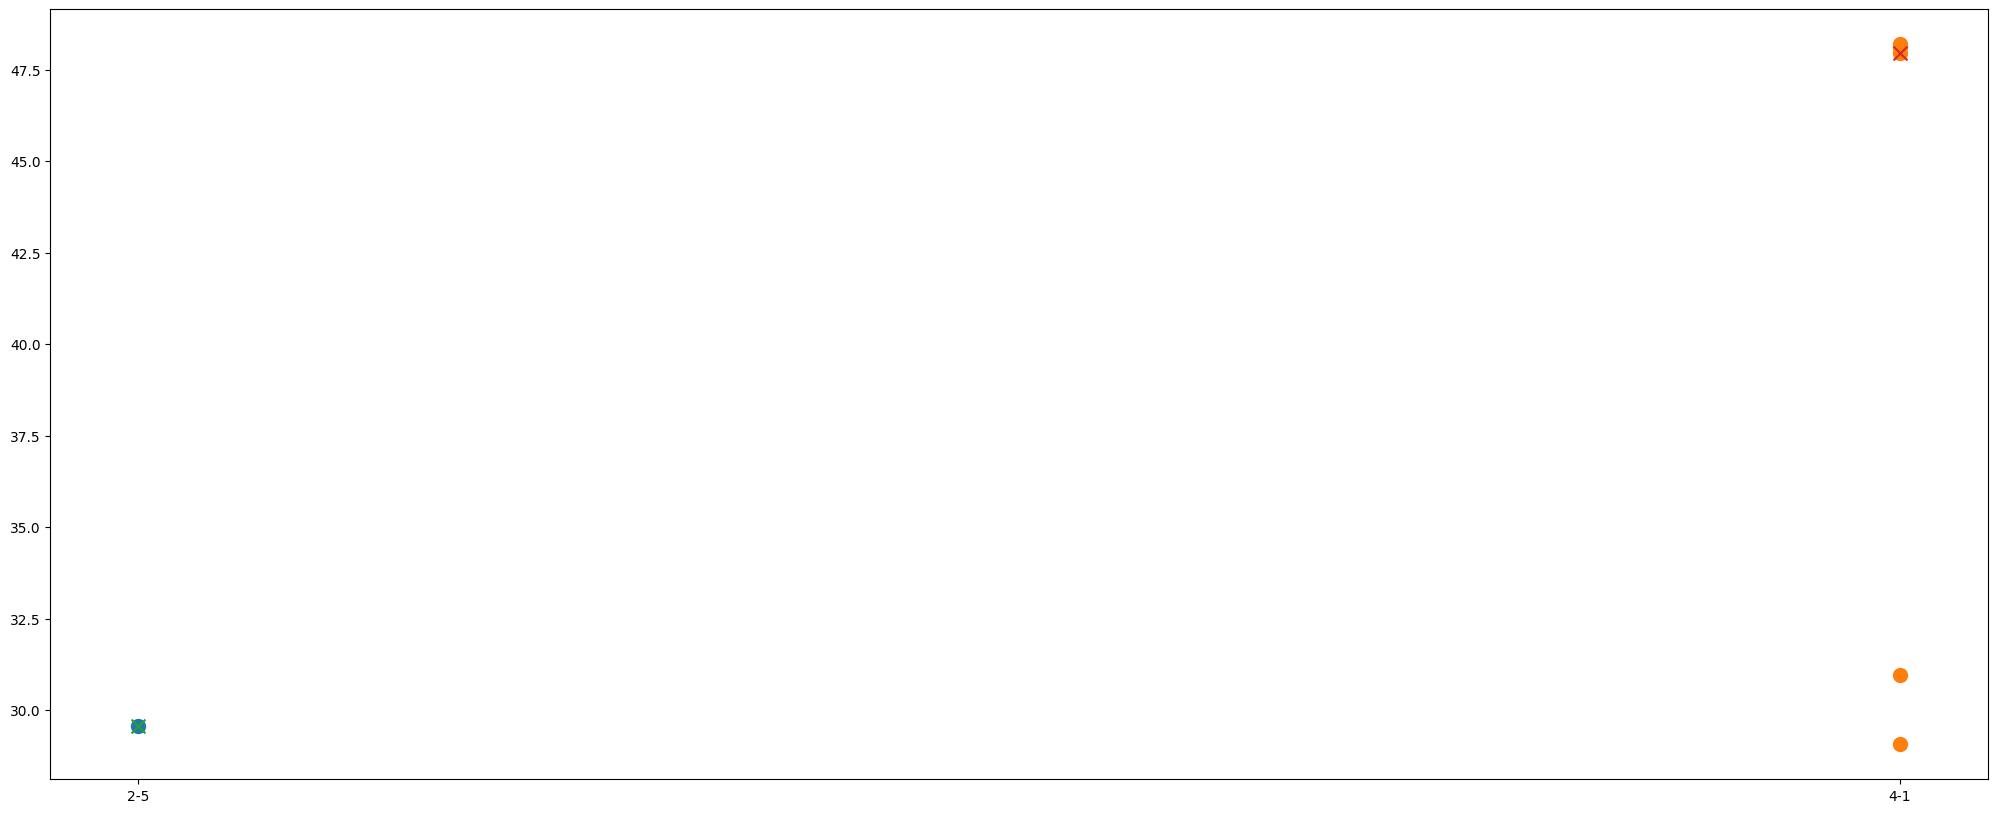

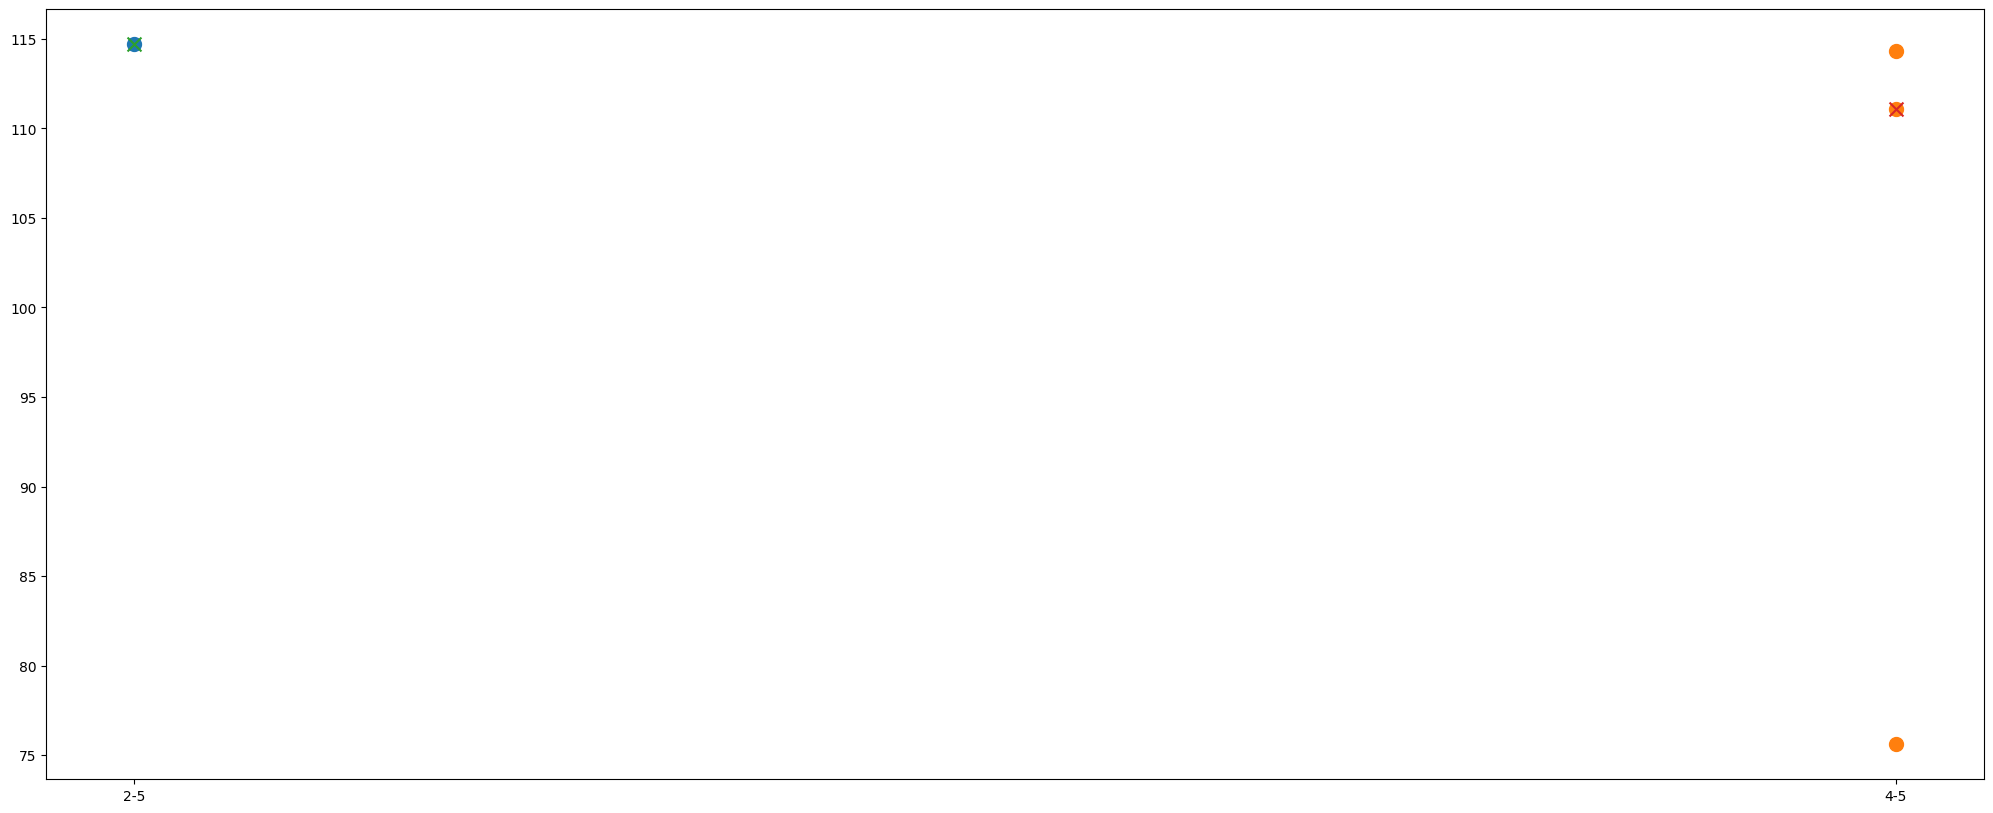

In [73]:
# fig, axs = plt.subplots(figsize=(25,10))
# # print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
# world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["net_times"]))]
# world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["net_times"]))]
# world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["net_times"][k])/30 for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["net_times"]))]

# # axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# # axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# # axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)


# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["net_times"][k] - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["net_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["net_times"]))]

axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)
axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)



fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["net_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["net_times"][k] -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["net_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_3_comp = [ i for i in world_3_con_3_comp if i > 0]
axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)

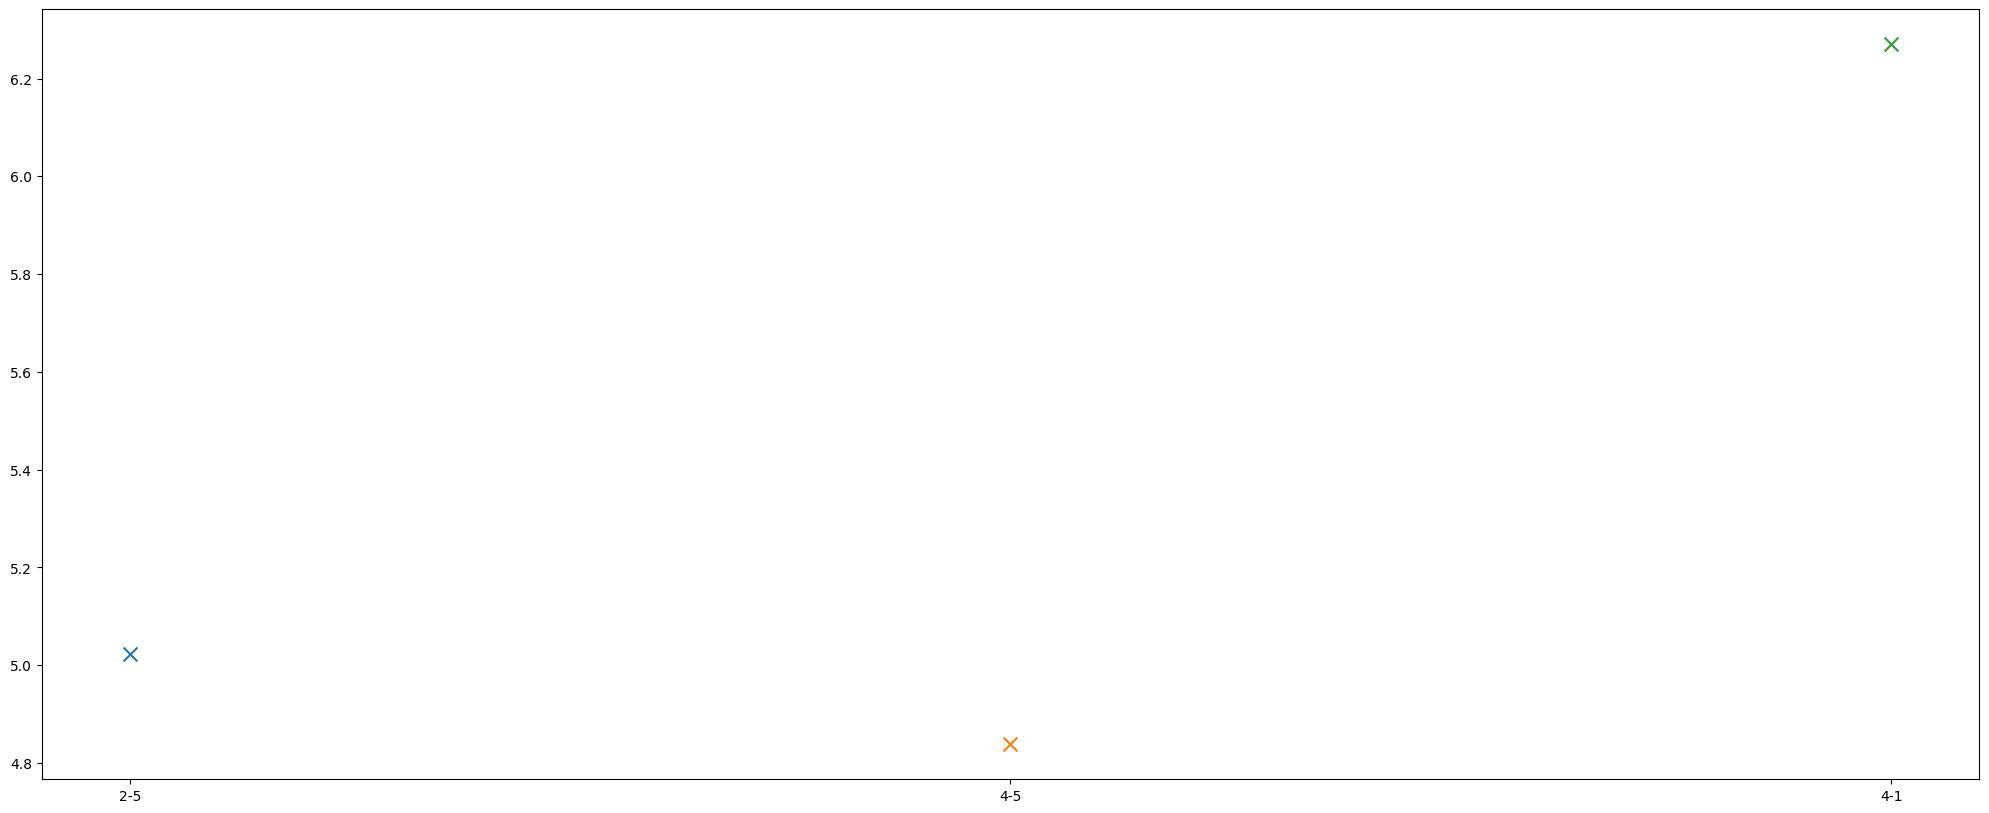

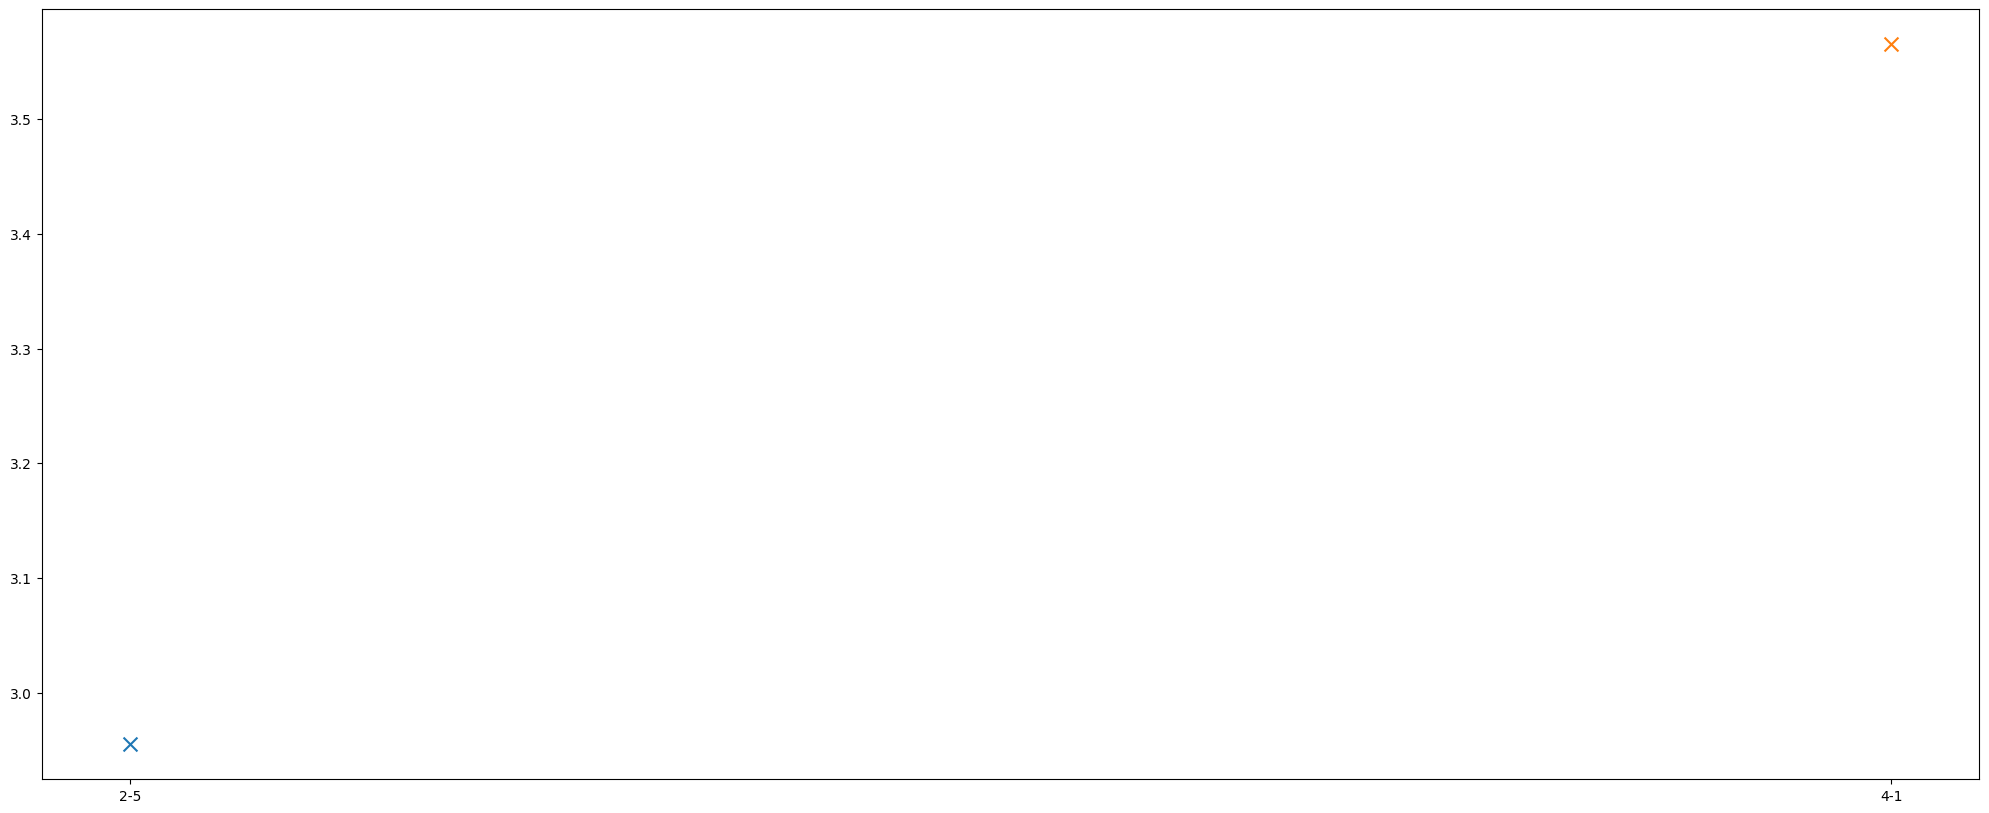

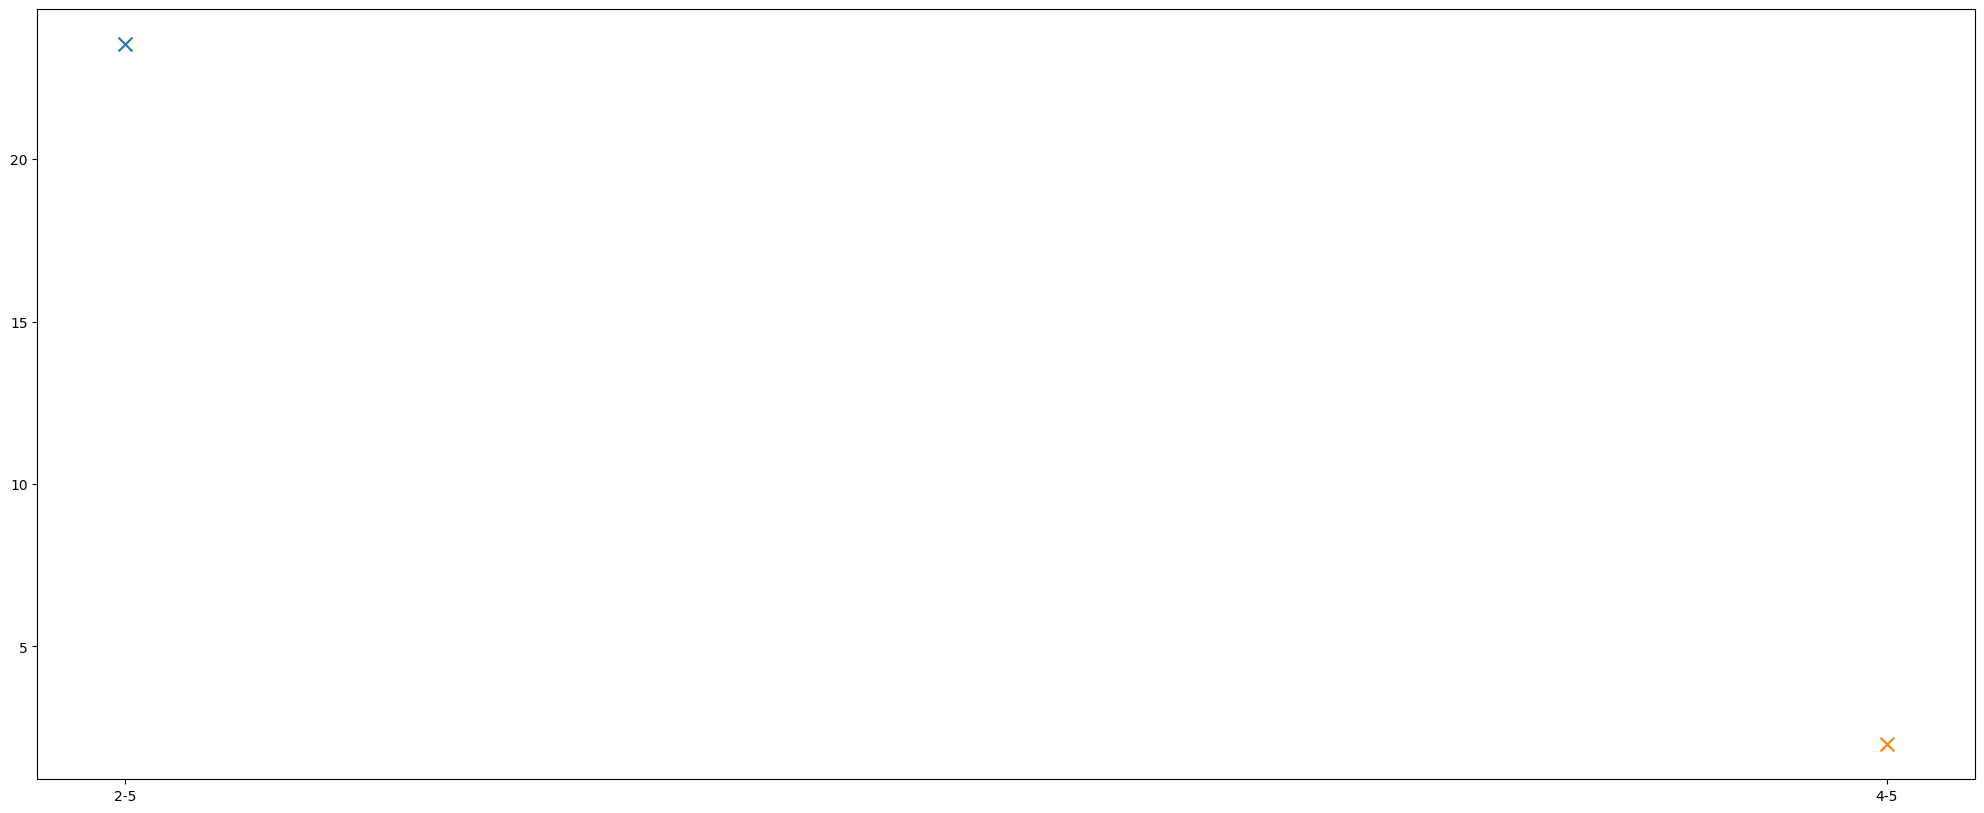

In [85]:
fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
world_1_con_1_comp = [(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"]))]
world_1_con_3_comp = [(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
world_1_con_5_comp = [(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"][k])/den for k in range(len(per_bank_stats["bramble-4-1"][1][5][0]["comp_times"]))]

# axs.scatter(["2-5"]*len(world_1_con_1_comp), world_1_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_1_con_3_comp), world_1_con_3_comp, s=100)
# axs.scatter(["4-1"]*len(world_1_con_5_comp), world_1_con_5_comp, s=100)


# axs.scatter("2-5", np.median(world_1_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_1_con_3_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_1_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_1_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_1_con_3_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_1_con_5_comp), marker="x", s=100)

fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][2][1][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_1_comp = [(per_bank_stats["bramble-2-5"][2][1][1]["comp_times"][k]/den - spec_warmup[k] ) for k in range(len(per_bank_stats["bramble-2-5"][2][1][0]["comp_times"]))]
# world_1_con_3_comp = [per_bank_stats["bramble-4-5"][1][3][0]["comp_times"][k] -  per_bank_stats["bramble-4-5"][1][3][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-5"][1][3][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-1"][2][5][r]["warmup"][k] for r in range(0, 1)]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_2_con_5_comp = [(per_bank_stats["bramble-4-1"][2][5][1]["comp_times"][k]/den -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]

# axs.scatter(["2-5"]*len(world_2_con_1_comp), world_2_con_1_comp, s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_2_con_5_comp, s=100)
# axs.scatter("2-5", np.median(world_2_con_1_comp), marker="x", s=100)
# axs.scatter("4-1", np.median(world_2_con_5_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_2_con_1_comp), marker="x", s=100)
axs.scatter("4-1", np.min(world_2_con_5_comp), marker="x", s=100)


fig, axs = plt.subplots(figsize=(25,10))
# print(per_bank_stats["bramble-2-5"][1][1][0]["comp_times"])
spec_warmup = [ sum([per_bank_stats["bramble-2-5"][3][1][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_1_comp = [(per_bank_stats["bramble-2-5"][3][1][2]["comp_times"][k]/30 -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-2-5"][3][1][0]["comp_times"]))]
spec_warmup = [ sum([per_bank_stats["bramble-4-5"][3][3][r]["warmup"][k] for r in range(0, 2)]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["warmup"]))]
spec_warmup = [ 0 for i in spec_warmup]
world_3_con_3_comp = [(per_bank_stats["bramble-4-5"][3][3][2]["comp_times"][k]/30 -  spec_warmup[k]) for k in range(len(per_bank_stats["bramble-4-5"][3][3][0]["comp_times"]))]
# world_2_con_5_comp = [per_bank_stats["bramble-4-1"][2][5][0]["comp_times"][k] -  per_bank_stats["bramble-4-1"][2][5][0]["warmup"][k] for k in range(len(per_bank_stats["bramble-4-1"][2][5][0]["comp_times"]))]
world_3_con_3_comp = [ i for i in world_3_con_3_comp if i > 0]
# axs.scatter(["2-5"]*len(world_3_con_1_comp), world_3_con_1_comp, s=100)
# axs.scatter(["4-5"]*len(world_3_con_3_comp), world_3_con_3_comp, s=100)


# axs.scatter("2-5", np.median(world_3_con_1_comp), marker="x", s=100)
# axs.scatter("4-5", np.median(world_3_con_3_comp), marker="x", s=100)

axs.scatter("2-5", np.min(world_3_con_1_comp), marker="x", s=100)
axs.scatter("4-5", np.min(world_3_con_3_comp), marker="x", s=100)
# axs.scatter(["4-1"]*len(world_2_con_5_comp), world_1_con_5_comp, s=100)